# Técnicas Avançadas para Clusters

O professou chapou e ao invés de ensinar a instalar as dependencias, ele mesmo extraiu oq é necessário e incluiu nos seguintes arquivos:
- [hopkins.py](../anexos/hopkins.py)  
- [metric.py](../anexos/metric.py)  
- [visual_assessment_of_tendency.py](../anexos/visual_assessment_of_tendency.py)  

## Preparando os dados

In [20]:
from sklearn import datasets
import numpy as np
from sklearn.preprocessing import scale
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from pyclustertend import ivat, vat, hopkins, assess_tendency_by_metric, assess_tendency_by_mean_metric_score

# import warnings
# warnings.filterwarnings('ignore', category=FutureWarning)

iris = datasets.load_iris()
cluster1 = scale(iris.data) # outra forma de normalizar os dados, porém mais simples, excelente para prototipar
cluster2 = scale(np.random.rand(150,4)) # gera uma matriz de dados aleatorios com a mesma dimensão da Iris
cluster2

array([[ 0.01231336,  0.93956554,  0.05245178,  0.64385284],
       [-1.10083203,  1.54776418,  0.79897633,  0.06267746],
       [-1.29531686,  0.80093743, -1.18712128,  0.64735328],
       [-0.01232706, -0.24883256,  0.53797662,  0.33915776],
       [ 0.91930658,  0.01729827, -0.78693585, -0.97264027],
       [-1.50361289, -1.23034959, -0.24021185, -1.52179511],
       [-1.32543379, -1.56370354,  0.0433583 , -1.55754827],
       [-0.07057095, -0.45232386, -1.09314213, -1.01673056],
       [-0.33507296, -0.68806414, -1.58122649, -1.45901689],
       [ 1.75997247, -0.22471734,  0.220056  ,  0.54882131],
       [ 0.92979735,  0.35777918, -0.4650186 ,  0.78972283],
       [ 1.02075053, -1.28978836, -1.1196015 ,  0.41314438],
       [-0.61965784, -0.45440709, -1.40277912,  0.35980632],
       [-0.76571233,  1.41771153,  0.64207405, -0.12072505],
       [ 0.97155127, -1.66254184,  0.266206  ,  0.91095709],
       [-0.2248636 ,  0.91006066,  0.49811144,  0.92628751],
       [ 1.35518854, -0.

## Construir Gráfico de Elbow

Pra visualmente ver quantos clusters são ideais

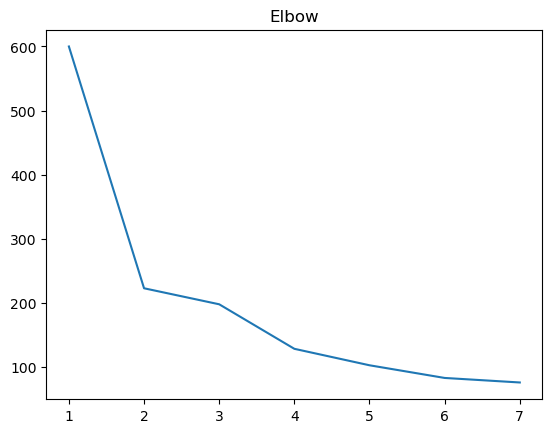

In [21]:
inertia = []
for i in range(1, 8):
    kmeans = KMeans(n_clusters=i, n_init='auto')
    kmeans.fit(cluster1)
    inertia.append(kmeans.inertia_)
plt.plot(range(1,8), inertia)
plt.title('Elbow')
plt.show()

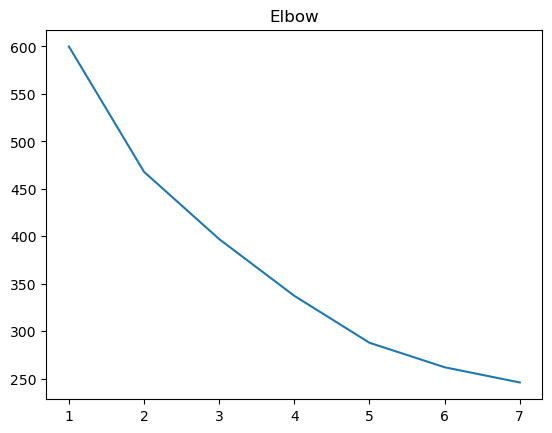

In [22]:
inertia = []
for i in range(1, 8):
    kmeans = KMeans(n_clusters=i, n_init='auto')
    kmeans.fit(cluster2)
    inertia.append(kmeans.inertia_)
plt.plot(range(1,8), inertia)
plt.title('Elbow')
plt.show()

## Estastistica de Hopkins

Quanto mais próximo de 0, melhor.
Quanto mais próximo de 1, significa que os dados são aleatorios, que não há uma clareza.

In [23]:
hopkins(cluster1,150)

0.19031557073525807

In [24]:
hopkins(cluster2,150)

0.49020050348110905

## Técnicas Visuais

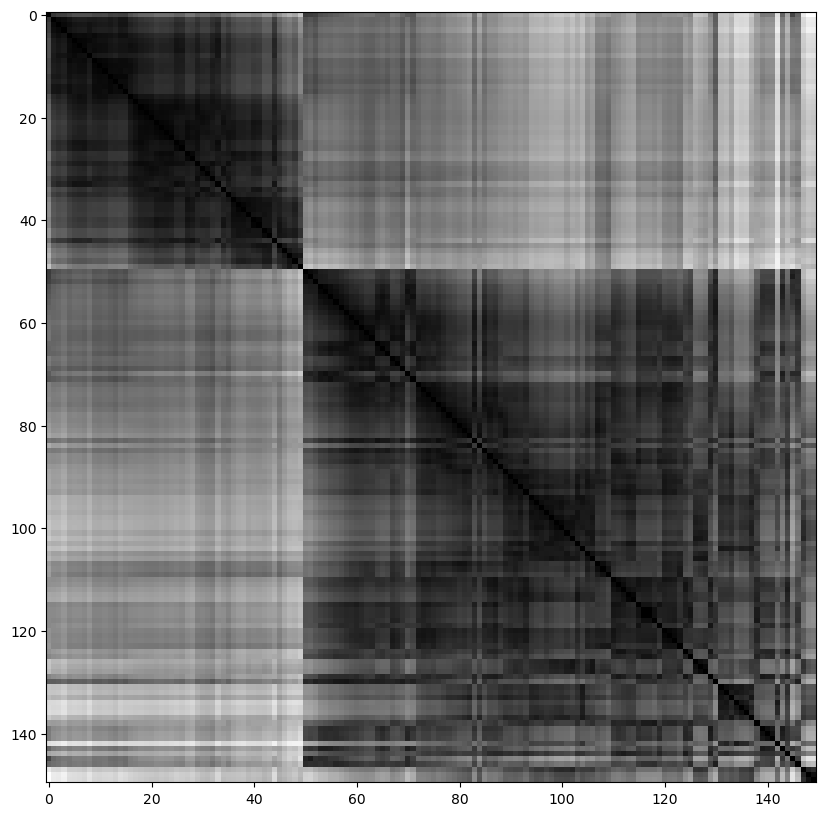

In [25]:
vat(cluster1)

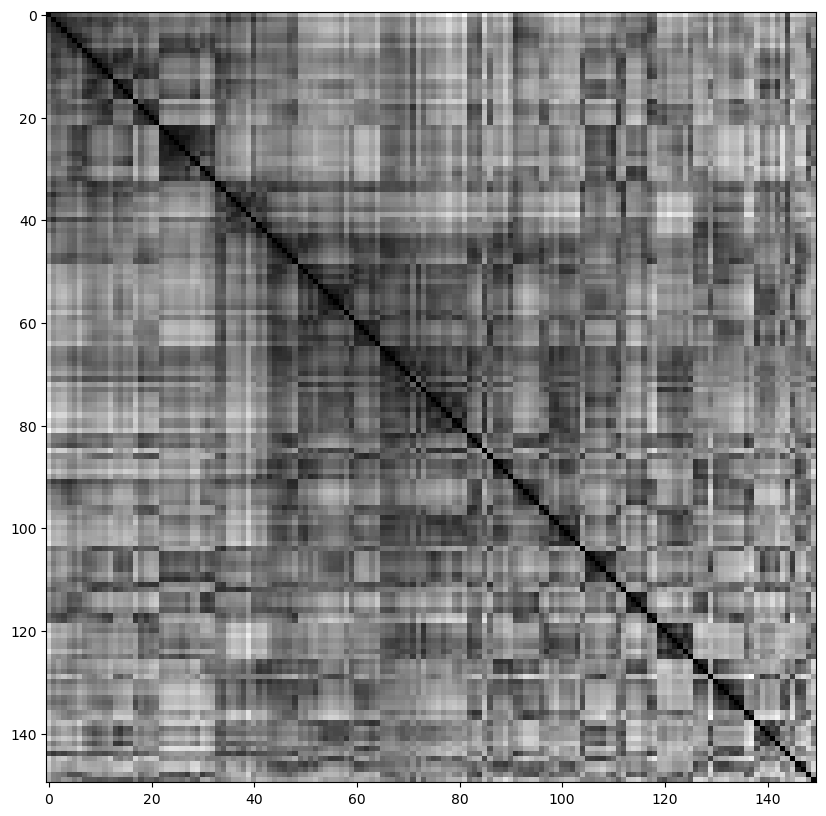

In [26]:
vat(cluster2)

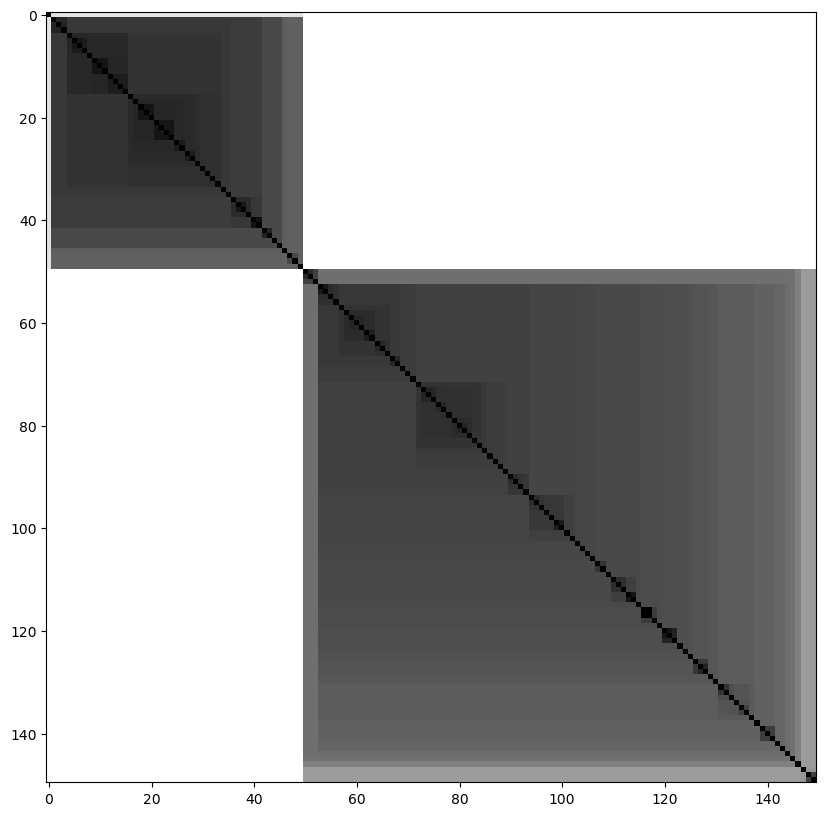

In [27]:
ivat(cluster1)

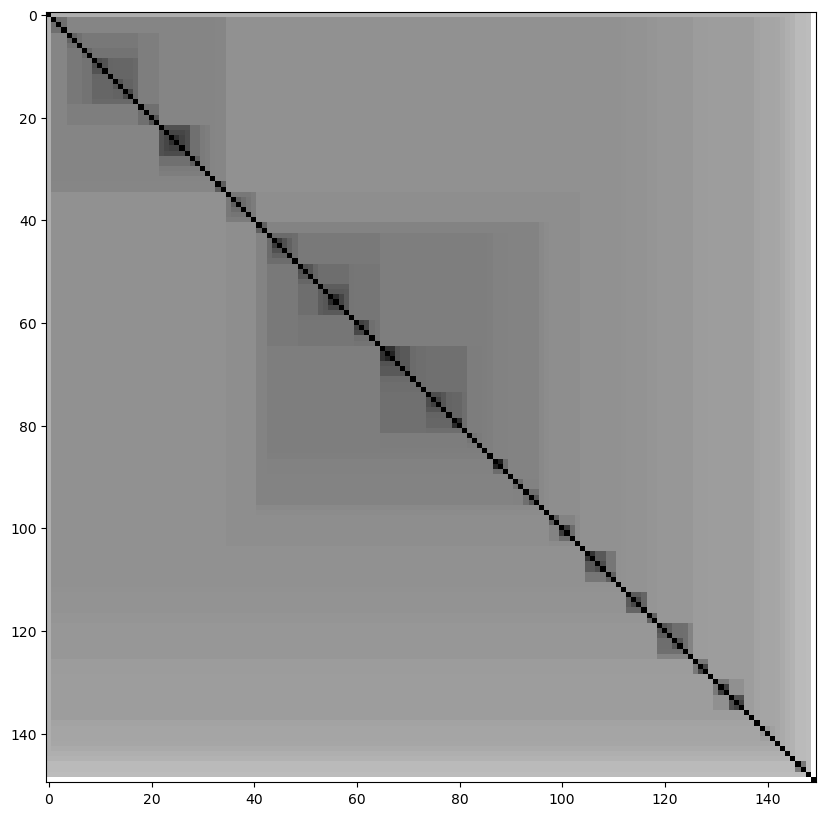

In [28]:
ivat(cluster2)

## Assess Tendency by Metric

Semelhante ao Elbow, porém independe de interpretação visual, pois ele analisa a correlação dos dados para sugerir a quantidade de clusters ideais.

In [ ]:
m = assess_tendency_by_metric(cluster1, 'silhouette', 5) # quantidade de clusters a serem avaliados, iniciando por 2
print(m)
# Exemplo de retorno: (2, array([0.58175005, 0.46304204, 0.38504541, 0.38766033]))
# Significa que ele entendeu que a quantidade ideal de clusters são 2 (0.58175005) - Busca o maior valor

(2, array([0.58175005, 0.46304204, 0.38504541, 0.38766033]))


In [ ]:
m = assess_tendency_by_metric(cluster1, 'davies_bouldin', 5) # quantidade de clusters a serem avaliados, iniciando por 2
print(m)
# Exemplo de retorno: (2, array([0.59331269, 0.83359495, 0.88627506, 1.18813434]))
# Significa que ele entendeu que a quantidade ideal de clusters tb são 2 (0.59331269) - Busca o menor valor

(2, array([0.59331269, 0.83359495, 0.88627506, 1.18813434]))


In [ ]:
m = assess_tendency_by_metric(cluster1, 'calinski_harabasz', 5) # quantidade de clusters a serem avaliados, iniciando por 2
print(m)
# Exemplo de retorno: (2, array([251.34933946, 241.42632349, 206.07292962, 188.55778599]))
# Significa que ele entendeu que a quantidade ideal de clusters tb são 2 (251.34933946) - Busca o maior valor

(2, array([251.34933946, 241.42632349, 206.07292962, 188.55778599]))


## Assess Tendency by Mean Metric Score

Faz as 3 comparações de uma unica vez (silhouette, davies_bouldin e calinski_harabasz) e trás o resultado da media

In [33]:
m = assess_tendency_by_mean_metric_score(cluster1, 5) # quantidade de clusters a serem avaliados, iniciando por 2
print(m)

2.0
